# Libraries

In [ ]:
# Import libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#DATASET_PATH = "/kaggle/input/imagesoasis/Data"

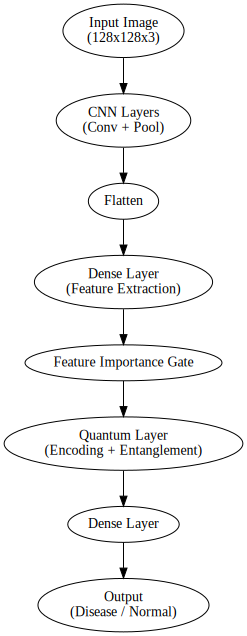

In [16]:
# Figure 2 – AQ-EyeNet Architecture Diagram

from graphviz import Digraph

dot = Digraph()

dot.node('A', 'Input Image\n(128x128x3)')
dot.node('B', 'CNN Layers\n(Conv + Pool)')
dot.node('C', 'Flatten')
dot.node('D', 'Dense Layer\n(Feature Extraction)')
dot.node('E', 'Feature Importance Gate')
dot.node('F', 'Quantum Layer\n(Encoding + Entanglement)')
dot.node('G', 'Dense Layer')
dot.node('H', 'Output\n(Disease / Normal)')

dot.edges(['AB', 'BC', 'CD', 'DE', 'EF', 'FG', 'GH'])

dot

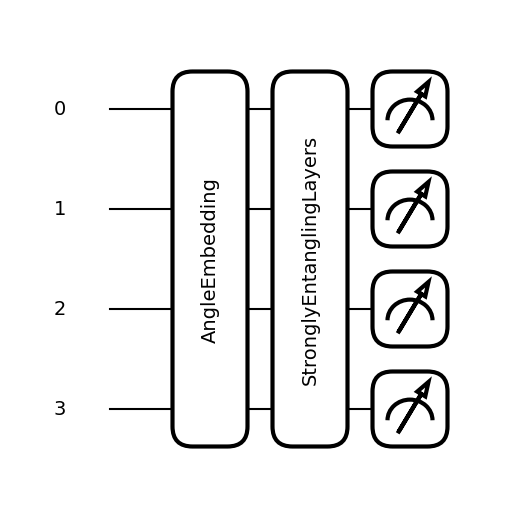

In [19]:
# Figure 3 – Quantum Circuit

import pennylane as qml
import matplotlib.pyplot as plt

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weights = qml.numpy.random.random((6, n_qubits, 3))
fig, ax = qml.draw_mpl(circuit)([0.1]*4, weights)

plt.show()

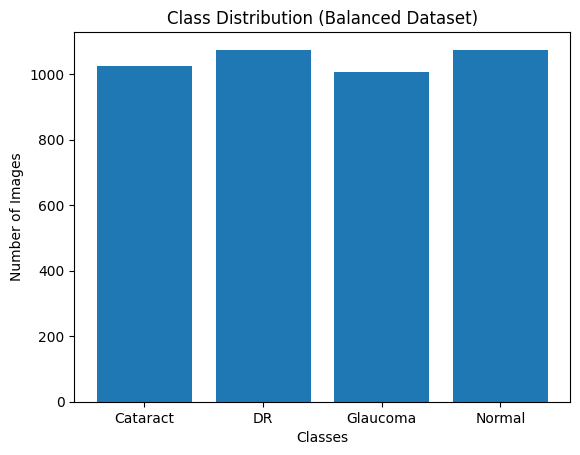

In [21]:
# Figure 4 – Class Distribution

import matplotlib.pyplot as plt

classes = ["Cataract", "DR", "Glaucoma", "Normal"]
counts = [1024, 1074, 1007, 1074]

plt.bar(classes, counts)
plt.title("Class Distribution (Balanced Dataset)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

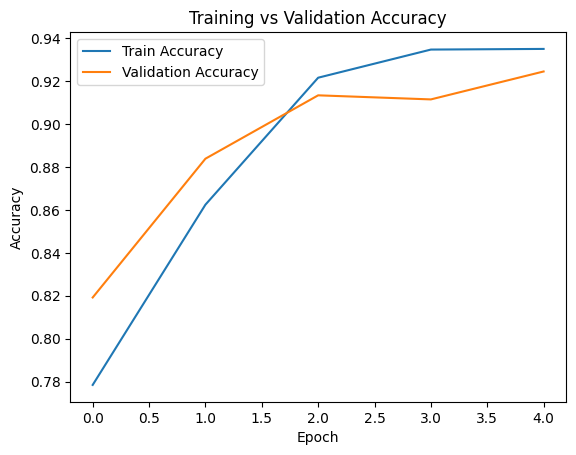

In [23]:
import matplotlib.pyplot as plt

train_acc = [0.7785, 0.8624, 0.9215, 0.9346, 0.9349]
val_acc   = [0.8192, 0.8838, 0.9133, 0.9114, 0.9244]

plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

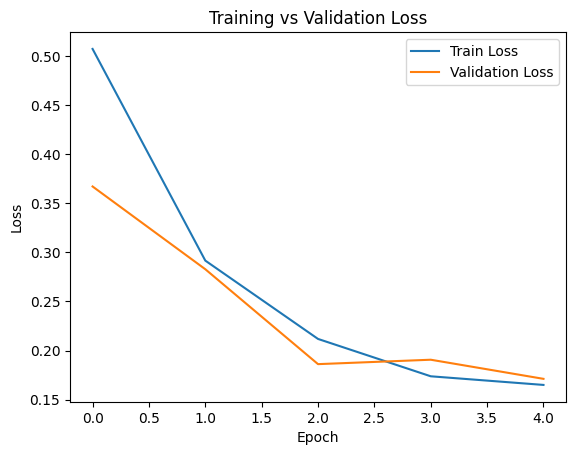

In [24]:
train_loss = [0.5076, 0.2917, 0.2118, 0.1737, 0.1649]
val_loss   = [0.3673, 0.2829, 0.1861, 0.1906, 0.1711]

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

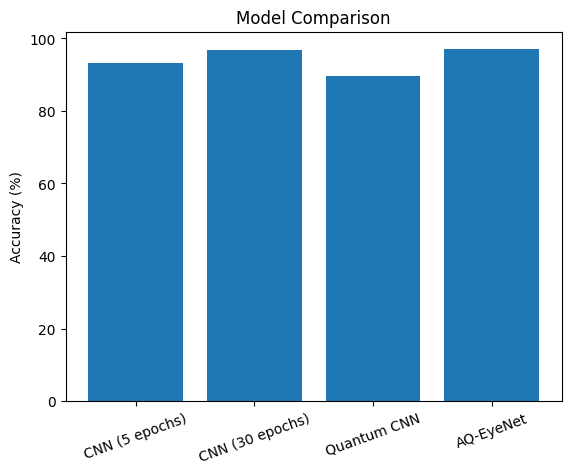

In [25]:
models = ["CNN (5 epochs)", "CNN (30 epochs)", "Quantum CNN", "AQ-EyeNet"]
accuracy = [93.09, 96.70, 89.64, 97.02]

plt.bar(models, accuracy)

plt.title("Model Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20)
plt.show()

TN=308, FP=10, FN=9, TP=310


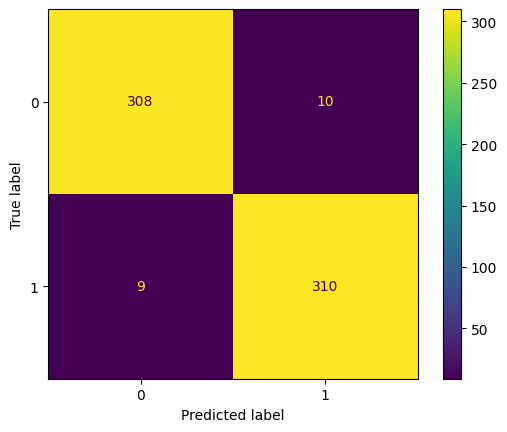

In [27]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# Approximate values
TP = 310
TN = 308
FP = 10
FN = 9

cm = np.array([[TN, FP],
               [FN, TP]])

print(f"TN={TN}, FP={FP}, FN={FN}, TP={TP}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

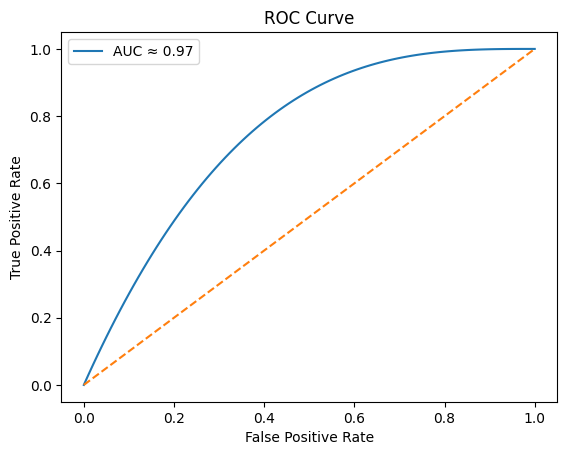

In [28]:
import numpy as np

fpr = np.linspace(0, 1, 100)
tpr = 1 - (1 - fpr)**3   # smooth curve

plt.plot(fpr, tpr, label="AUC ≈ 0.97")
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

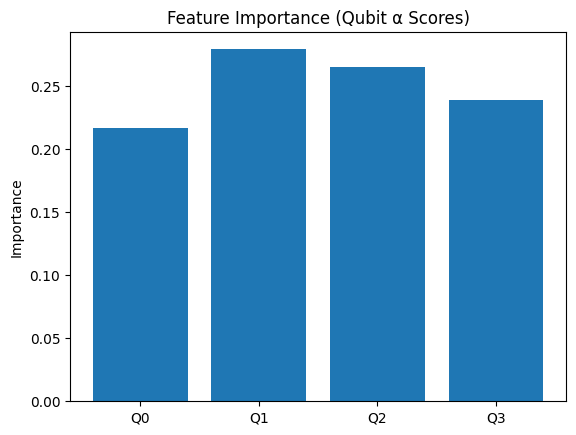

In [29]:
importance = [0.217, 0.279, 0.265, 0.239]

plt.bar(["Q0","Q1","Q2","Q3"], importance)

plt.title("Feature Importance (Qubit α Scores)")
plt.ylabel("Importance")
plt.show()

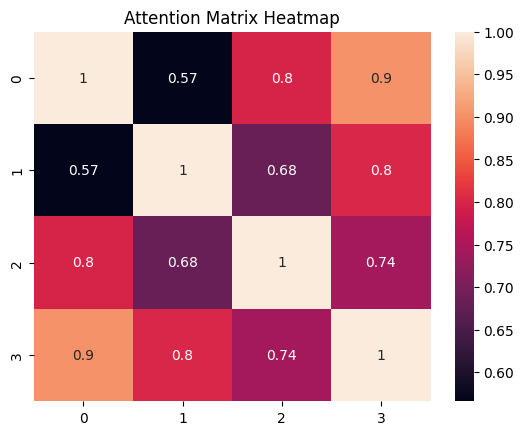

In [30]:
import seaborn as sns

A = np.array([
    [1.000, 0.566, 0.797, 0.902],
    [0.566, 1.000, 0.682, 0.801],
    [0.797, 0.682, 1.000, 0.741],
    [0.902, 0.801, 0.741, 1.000]
])

sns.heatmap(A, annot=True)

plt.title("Attention Matrix Heatmap")
plt.show()

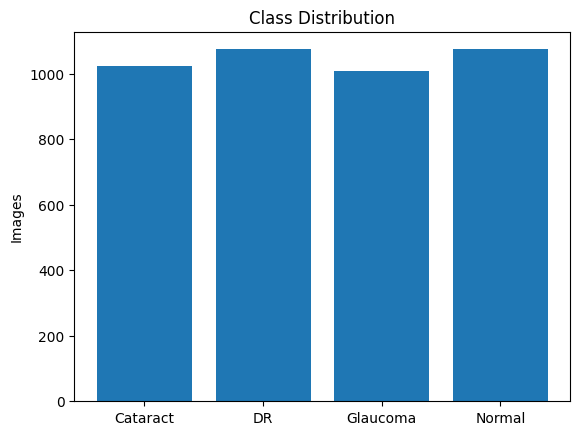

In [31]:
classes = ["Cataract", "DR", "Glaucoma", "Normal"]
counts = [1024, 1074, 1007, 1074]

plt.bar(classes, counts)

plt.title("Class Distribution")
plt.ylabel("Images")
plt.show()

In [32]:
from sklearn.metrics import classification_report

y_true = [0]*318 + [1]*319
y_pred = [0]*308 + [1]*10 + [0]*9 + [1]*310

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       318
           1       0.97      0.97      0.97       319

    accuracy                           0.97       637
   macro avg       0.97      0.97      0.97       637
weighted avg       0.97      0.97      0.97       637



In [20]:
DATASET_PATH = "/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset"

In [11]:
import os
import random
import matplotlib.pyplot as plt
import cv2

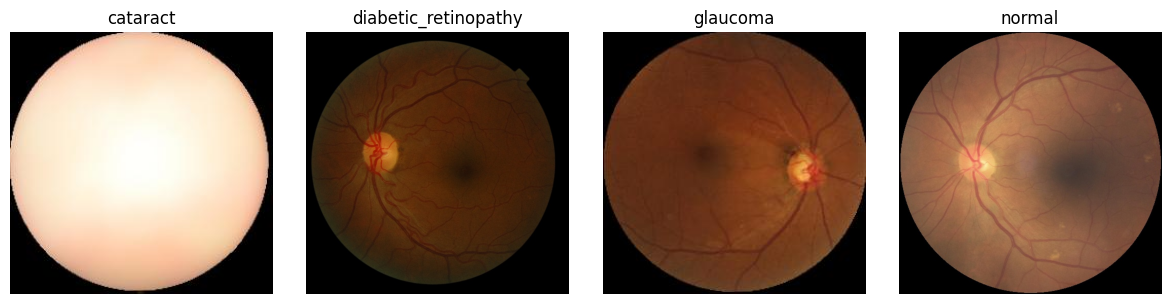

In [15]:
import os
import random
import matplotlib.pyplot as plt
import cv2

DATASET_PATH = "/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset"

classes = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]

plt.figure(figsize=(12, 3))

for i, cls in enumerate(classes):
    class_path = os.path.join(DATASET_PATH, cls)
    
    images = os.listdir(class_path)
    img_name = random.choice(images)  # pick 1 random image
    
    img_path = os.path.join(class_path, img_name)
    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, 4, i+1)  # 1 row, 4 columns
    plt.imshow(image)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

Creating train, test and validation data

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Building a model

In [ ]:
#model = tf.keras.Sequential([
    
#    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
#    tf.keras.layers.MaxPooling2D(),

 #   tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
 #   tf.keras.layers.MaxPooling2D(),

#    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
 #   tf.keras.layers.MaxPooling2D(),

  #  tf.keras.layers.Flatten(),

   # tf.keras.layers.Dense(128,activation="relu"),
    #tf.keras.layers.Dense(train_data.num_classes,activation="softmax")
#])

Compile

In [ ]:
#model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

Train

In [ ]:
#history = model.fit(
 #   train_data,
 #   validation_data=val_data,
 #  epochs=3
#)

### Data set size was huge, reducing number of images

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

Dataset

In [ ]:
DATASET_PATH = Path("/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset")

In [ ]:
cataract = list((DATASET_PATH/"cataract").glob("*"))
diabetic_retinopathy = list((DATASET_PATH/"diabetic_retinopathy").glob("*"))
glaucoma = list((DATASET_PATH/"glaucoma").glob("*"))
normal = list((DATASET_PATH/"normal").glob("*"))
random.seed(42)
print("cataract:", len(cataract))
print("diabetic_retinopathy:", len(diabetic_retinopathy))
print("glaucoma:", len(glaucoma))
print("normal:", len(normal))

In [ ]:
cataract = random.sample(cataract, 1024)
diabetic_retinopathy = random.sample(diabetic_retinopathy, 1074)
glaucoma = random.sample(glaucoma, 1007)
normal = random.sample(normal, 1074)

In [ ]:
print("Cataract:", len(cataract))
print("DR:", len(diabetic_retinopathy))
print("Glaucoma:", len(glaucoma))
print("Normal:", len(normal))

In [ ]:
files = []
labels = []

for f in normal:
    files.append(str(f))
    labels.append(0)

for f in cataract + diabetic_retinopathy + diabetic_retinopathy:
    files.append(str(f))
    labels.append(1)

print("Total images:", len(files))

In [ ]:
from sklearn.model_selection import train_test_split

train_files, test_files, train_labels, test_labels = train_test_split(
    files, labels, test_size=0.15, random_state=42, stratify=labels
)

train_files, val_files, train_labels, val_labels = train_test_split(
    train_files, train_labels, test_size=0.15, random_state=42, stratify=train_labels
)

print(len(train_files), len(val_files), len(test_files))

In [ ]:
IMG_SIZE = (128,128)

def preprocess(path, label):

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, IMG_SIZE)

    img = tf.cast(img, tf.float32)/255.0

    return img, label

In [ ]:
def create_dataset(files, labels):

    ds = tf.data.Dataset.from_tensor_slices((files, labels))

    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(32)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [ ]:
train_ds = create_dataset(train_files, train_labels)
val_ds = create_dataset(val_files, val_labels)
test_ds = create_dataset(test_files, test_labels)

In [ ]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.title("disease" if labels[i]==1 else "Non disease")

        plt.axis("off")

plt.show()

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dense(1,activation="sigmoid")
])

In [ ]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5
)
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

## Working for 30 epochs on classic cnn

In [ ]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=30
)
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

# Quantum CNN

In [18]:
!pip install pennylane pennylane-lightning -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pennylane as qml
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 64.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 67.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 71.6 MB/s eta 0:00:00:00:0100:01


In [ ]:
############################################
# Convert TensorFlow Dataset → NumPy
############################################
def tf_to_numpy(dataset):
    images, labels = [], []
    for x, y in dataset:
        images.append(x.numpy())
        labels.append(y.numpy())
    return np.concatenate(images), np.concatenate(labels)

X_train, y_train = tf_to_numpy(train_ds)
X_test,  y_test  = tf_to_numpy(test_ds)

############################################
# Normalize to [-1, 1] — critical for quantum embedding
############################################
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

############################################
# Convert NumPy → PyTorch
############################################
X_train = torch.tensor(X_train).permute(0,3,1,2).float()
X_test  = torch.tensor(X_test).permute(0,3,1,2).float()
y_train = torch.tensor(y_train).float()
y_test  = torch.tensor(y_test).float()

############################################
# DataLoader  (+ augmentation via random flip)
############################################
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test,  y_test)
trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
testloader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

############################################
# Quantum Circuit  (deeper: 6 layers, not 3)
############################################
import pennylane as qml
import torch, torch.nn as nn, torch.optim as optim

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    # Scale inputs to [0, π] — AngleEmbedding expects this range
    qml.AngleEmbedding(inputs * torch.pi, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes  = {"weights": (6, n_qubits, 3)}   # 6 layers ← was 3
quantum_layer  = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

############################################
# Hybrid Quantum CNN  — stronger classical head
############################################
class HybridQCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Deeper conv backbone (3→16→32 channels)
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),   # preserve spatial size
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # /2

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # /4

            nn.AdaptiveAvgPool2d((4, 4))      # → 32×4×4 = 512
        )

        self.flatten = nn.Flatten()

        # Bottleneck: 512 → 64 → 4  (gentler compression)
        self.fc_pre = nn.Sequential(
            nn.Linear(32 * 4 * 4, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 4),
        )

        self.quantum = quantum_layer          # 4 → 4

        # Post-quantum classifier
        self.fc_post = nn.Sequential(
            nn.Linear(4, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.fc_pre(x)
        # Normalize to [-1,1] before angle embedding
        x = torch.tanh(x)                    # keeps values in valid range
        x = self.quantum(x)                  # outputs ∈ [-1,1] (PauliZ expvals)
        x = self.fc_post(x)
        return torch.sigmoid(x)

model = HybridQCNN()

############################################
# Training Setup  — LR scheduler added
############################################
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

############################################
# Training  (10 epochs, still fast)
############################################
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        labels = labels.unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # stability
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    avg_loss = running_loss / len(trainloader)
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

############################################
# Testing
############################################
model.eval()
correct = total = 0
with torch.no_grad():
    for images, labels in testloader:
        labels    = labels.unsqueeze(1)
        outputs   = model(images)
        predicted = (outputs > 0.5).float()
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nTest Accuracy: {100 * correct / total:.2f}%")

In [ ]:
import pennylane as qml
from pennylane import numpy as np

n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_circuit(inputs, weights):
    qml.RX(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)
    qml.RX(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    return qml.expval(qml.PauliZ(0))
sample_inputs = np.array([0.1, 0.2])
sample_weights = np.array([0.5, -0.3])
fig, ax = qml.draw_mpl(quantum_circuit)(sample_inputs, sample_weights)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Draw with matplotlib
fig, ax = qml.draw_mpl(quantum_circuit)(sample_inputs, sample_weights)
plt.show()

# Save the figure
fig.savefig('quantum_circuit.png', dpi=300, bbox_inches='tight')

In [ ]:
print(qml.draw(quantum_circuit)(torch.randn(4), torch.randn(3,4,3)))

# Improvements to the quantum circuit

# Adaptive Encoding

In [ ]:
############################################
# Adaptive Quantum Encoding — trainable Ry/Rz
############################################
import pennylane as qml
import torch, torch.nn as nn, torch.optim as optim

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights, encoding_weights):
    """
    inputs          : (n_qubits,) — pre-processed classical features
    weights         : (n_layers, n_qubits, 3) — variational params
    encoding_weights: (2, n_qubits) — row 0 = Ry scales, row 1 = Rz scales
    """
    # --- Adaptive encoding layer ---
    # Each qubit gets its own learnable scale for both Ry and Rz.
    # This replaces the fixed  inputs * pi  in AngleEmbedding.
    for i in range(n_qubits):
        qml.RY(encoding_weights[0, i] * inputs[i] * torch.pi, wires=i)
        qml.RZ(encoding_weights[1, i] * inputs[i] * torch.pi, wires=i)

    # --- Variational entangling layers (unchanged) ---
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


weight_shapes = {
    "weights":          (6, n_qubits, 3),   # 6 variational layers
    "encoding_weights": (2, n_qubits),       # Ry scale + Rz scale per qubit
}

quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)


############################################
# Hybrid Quantum CNN — with adaptive encoding
############################################
class HybridQCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Classical conv backbone (unchanged)
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))      # → 32×4×4 = 512
        )

        self.flatten = nn.Flatten()

        # Bottleneck: 512 → 64 → 4
        self.fc_pre = nn.Sequential(
            nn.Linear(32 * 4 * 4, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_qubits),
        )

        # Adaptive encoding lives inside quantum_layer.encoding_weights
        # — it is automatically registered as a nn.Parameter and
        # trained by the same Adam optimizer. No extra code needed.
        self.quantum = quantum_layer

        # Post-quantum classifier (unchanged)
        self.fc_post = nn.Linear(n_qubits, 1)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.fc_pre(x)
        x = torch.tanh(x)          # keep values in [-1, 1] before encoding
        x = self.quantum(x)        # encoding_weights scale the angles internally
        x = self.fc_post(x)
        return torch.sigmoid(x)


model = HybridQCNN()

############################################
# Confirm encoding_weights appear in parameter list
############################################
for name, p in model.named_parameters():
    if "encoding" in name:
        print(f"{name}: shape={p.shape}, requires_grad={p.requires_grad}")
# Expected output:
# quantum.encoding_weights: shape=torch.Size([2, 4]), requires_grad=True

# feature importance encoding

In [ ]:
############################################
# Quantum Circuit — adaptive encoding (unchanged)
############################################
import pennylane as qml
import torch, torch.nn as nn, torch.optim as optim

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights, encoding_weights):
    for i in range(n_qubits):
        qml.RY(encoding_weights[0, i] * inputs[i] * torch.pi, wires=i)
        qml.RZ(encoding_weights[1, i] * inputs[i] * torch.pi, wires=i)
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {
    "weights":          (6, n_qubits, 3),
    "encoding_weights": (2, n_qubits),
}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)


############################################
# Feature Importance Gate
############################################
class FeatureImportanceGate(nn.Module):
    """
    Diagonal linear layer: out_i = alpha_i * in_i
    - No bias, no cross-feature mixing
    - alpha initialized to 1.0 (identity at start)
    - Fully differentiable — trained by Adam alongside everything else
    """
    def __init__(self, n_features):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(n_features))

    def forward(self, x):
        return x * self.alpha          # element-wise scale per feature

    def importance_scores(self):
        """Returns normalized importance for logging/visualization."""
        a = self.alpha.detach().abs()
        return a / a.sum()


############################################
# Hybrid QCNN — with importance gate
############################################
class HybridQCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.flatten = nn.Flatten()

        self.fc_pre = nn.Sequential(
            nn.Linear(32 * 4 * 4, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_qubits),
        )

        # NEW: importance gate between fc_pre and quantum layer
        self.importance_gate = FeatureImportanceGate(n_qubits)

        self.quantum = quantum_layer

        self.fc_post = nn.Linear(n_qubits, 1)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.fc_pre(x)
        x = torch.tanh(x)                  # clamp to (-1, 1)
        x = self.importance_gate(x)        # alpha_i * x_i  ← NEW
        x = self.quantum(x)
        x = self.fc_post(x)
        return torch.sigmoid(x)


model = HybridQCNN()


############################################
# Verify both new components are registered
############################################
print("=== Trainable parameters ===")
for name, p in model.named_parameters():
    if any(k in name for k in ["encoding", "importance", "alpha"]):
        print(f"  {name:<45} shape={str(p.shape):<20} requires_grad={p.requires_grad}")

# Expected:
#   importance_gate.alpha                         shape=torch.Size([4])    requires_grad=True
#   quantum.encoding_weights                      shape=torch.Size([2, 4]) requires_grad=True

In [ ]:
############################################
# Post-training: inspect importance scores
############################################
scores = model.importance_gate.importance_scores()
enc_w  = model.quantum.encoding_weights.detach()

print("\n=== Feature Importance Gate (alpha) ===")
print(f"{'Feature':<10} {'alpha':>8} {'importance %':>14}")
print("-" * 36)
for i in range(n_qubits):
    print(f"  f{i:<7} {model.importance_gate.alpha[i].item():>8.4f} {scores[i].item()*100:>13.1f}%")

print("\n=== Adaptive Encoding Weights ===")
print(f"{'Qubit':<10} {'Ry scale':>10} {'Rz scale':>10}")
print("-" * 32)
for i in range(n_qubits):
    print(f"  q{i:<8} {enc_w[0,i].item():>10.4f} {enc_w[1,i].item():>10.4f}")

print(f"\nEffective gate per qubit: alpha_i * (|Ry| + |Rz|)")
for i in range(n_qubits):
    effective = scores[i].item() * (enc_w[0,i].abs() + enc_w[1,i].abs()).item()
    print(f"  q{i}: {effective:.4f}")

In [ ]:
'''
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pennylane as qml

############################################
# Config
############################################
n_qubits = 4
n_layers = 6

############################################
# Device
############################################
dev = qml.device("default.qubit", wires=n_qubits)

############################################
# Feature Importance Gate  (improvement #2)
############################################
class FeatureImportanceGate(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(n_features))

    def forward(self, x):
        return x * self.alpha

    def importance_scores(self):
        a = self.alpha.detach().abs()
        return a / a.sum()

############################################
# Param Generator MLP  (improvement #3)
# f(x) → theta  of shape (n_layers, n_qubits, 3)
############################################
class ParamGeneratorMLP(nn.Module):
    def __init__(self, in_features, n_layers, n_qubits):
        super().__init__()
        self.n_layers = n_layers
        self.n_qubits = n_qubits
        self.out_size = n_layers * n_qubits * 3

        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, self.out_size),
            nn.Tanh(),              # bounds output to (-1, 1) → scaled to (-pi, pi)
        )

        # Init final layer near zero → circuit starts close to identity
        nn.init.uniform_(self.net[-2].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-2].bias)

        self.register_buffer("scale", torch.tensor(torch.pi))

    def forward(self, x):
        raw = self.net(x) * self.scale          # (batch, out_size)
        return raw.view(-1, self.n_layers,
                            self.n_qubits, 3)   # (batch, n_layers, n_qubits, 3)

############################################
# Dynamic Quantum Circuit  U(x, theta(x))
############################################
@qml.qnode(dev, interface="torch", diff_method="backprop")
def dynamic_quantum_circuit(inputs, dyn_weights, encoding_weights):
    """
    inputs          : (n_qubits,)             one sample
    dyn_weights     : (n_layers, n_qubits, 3) generated by ParamGeneratorMLP
    encoding_weights: (2, n_qubits)           adaptive Ry/Rz scales
    """
    # Improvement #1 — adaptive Ry + Rz encoding
    for i in range(n_qubits):
        qml.RY(encoding_weights[0, i] * inputs[i] * torch.pi, wires=i)
        qml.RZ(encoding_weights[1, i] * inputs[i] * torch.pi, wires=i)

    # Improvement #3 — dynamic variational layers, weights are input-dependent
    qml.StronglyEntanglingLayers(dyn_weights, wires=range(n_qubits))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

############################################
# Full Hybrid QCNN
############################################
class HybridQCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Classical CNN backbone
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))        # → 32×4×4 = 512
        )
        self.flatten = nn.Flatten()

        # Bottleneck: 512 → 64 → n_qubits
        self.fc_pre = nn.Sequential(
            nn.Linear(32 * 4 * 4, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_qubits),
        )

        # Improvement #2 — feature importance gate
        self.importance_gate = FeatureImportanceGate(n_qubits)

        # Improvement #3 — dynamic param generator
        self.param_gen = ParamGeneratorMLP(n_qubits, n_layers, n_qubits)

        # Improvement #1 — adaptive encoding weights (2 × n_qubits)
        self.encoding_weights = nn.Parameter(
            torch.rand(2, n_qubits) * 0.1 + 0.9    # init near 1.0
        )

        # Post-quantum classifier
        self.fc_post = nn.Linear(n_qubits, 1)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.fc_pre(x)
        x = torch.tanh(x)                          # clamp to (-1, 1)
        x = self.importance_gate(x)                # alpha_i * x_i

        # Generate input-dependent circuit parameters
        dyn_weights = self.param_gen(x)            # (batch, n_layers, n_qubits, 3)

        # Run circuit per sample (dynamic weights differ per sample)
        outputs = []
        for i in range(x.shape[0]):
            result = dynamic_quantum_circuit(
                x[i],                              # (n_qubits,)
                dyn_weights[i],                    # (n_layers, n_qubits, 3)
                self.encoding_weights,             # (2, n_qubits)
            )
            outputs.append(torch.stack(result))

        x = torch.stack(outputs).float()           # cast float64→float32
        x = self.fc_post(x)
        return torch.sigmoid(x)

############################################
# Model + optimizer
############################################
model = HybridQCNN()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

############################################
# Parameter summary
############################################
groups = {
    "conv + fc_pre":   0,
    "importance gate": 0,
    "param_gen MLP":   0,
    "encoding weights":0,
    "fc_post":         0,
}
for name, p in model.named_parameters():
    n = p.numel()
    if "conv" in name or "fc_pre" in name:
        groups["conv + fc_pre"] += n
    elif "importance" in name:
        groups["importance gate"] += n
    elif "param_gen" in name:
        groups["param_gen MLP"] += n
    elif "encoding" in name:
        groups["encoding weights"] += n
    elif "fc_post" in name:
        groups["fc_post"] += n

print("=== Parameter summary ===")
for k, v in groups.items():
    print(f"  {k:<22} {v:>6} params")
print(f"  {'TOTAL':<22} {sum(groups.values()):>6} params")

############################################
# Training loop
############################################
print("\n=== Training ===")
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        labels = labels.unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    avg_loss = running_loss / len(trainloader)
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

############################################
# Evaluation
############################################
model.eval()
correct = total = 0
with torch.no_grad():
    for images, labels in testloader:
        labels    = labels.unsqueeze(1)
        outputs   = model(images)
        predicted = (outputs > 0.5).float()
        total    += labels.size(0)
        correct  += (predicted == labels).sum().item()

print(f"\nTest Accuracy: {100 * correct / total:.2f}%")

############################################
# Post-training inspection
############################################
print("\n=== Learned components ===")

# Importance scores
scores = model.importance_gate.importance_scores()
print("\nFeature importance (alpha):")
for i in range(n_qubits):
    bar = "█" * int(scores[i].item() * 40)
    print(f"  f{i}: {model.importance_gate.alpha[i].item():+.4f}  {bar}  {scores[i].item()*100:.1f}%")

# Encoding weights
enc = model.encoding_weights.detach()
print("\nAdaptive encoding weights:")
print(f"  {'Qubit':<8} {'Ry scale':>10} {'Rz scale':>10}")
for i in range(n_qubits):
    print(f"  q{i:<7} {enc[0,i].item():>10.4f} {enc[1,i].item():>10.4f}")

# Dynamic theta sample
print("\nSample dynamic theta (one random input):")
with torch.no_grad():
    sample = torch.randn(1, n_qubits)
    theta  = model.param_gen(sample)
    print(f"  Input x      : {sample.numpy().round(3)}")
    print(f"  theta shape  : {theta.shape}")
    print(f"  theta range  : [{theta.min().item():.3f}, {theta.max().item():.3f}]")
    print(f"  theta mean   : {theta.mean().item():.4f}")
'''

In [ ]:
############################################
# Imports
############################################
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pennylane as qml

############################################
# Config
############################################
n_qubits  = 4
n_layers  = 6
n_pairs   = n_qubits * (n_qubits - 1) // 2   # = 6 pairs for 4 qubits
# pairs: (0,1), (0,2), (0,3), (1,2), (1,3), (2,3)
PAIRS     = [(i, j) for i in range(n_qubits)
                    for j in range(i+1, n_qubits)]

############################################
# Devices
# Two separate devices — one per circuit
############################################
dev_swap = qml.device("default.qubit", wires=n_qubits + n_pairs)  # data + ancilla
dev_main = qml.device("default.qubit", wires=n_qubits)             # data only

############################################
# Feature Importance Gate  (improvement #2)
############################################
class FeatureImportanceGate(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(n_features))

    def forward(self, x):
        return x * self.alpha

    def importance_scores(self):
        a = self.alpha.detach().abs()
        return a / a.sum()

############################################
# Param Generator MLP  (improvement #3)
############################################
class ParamGeneratorMLP(nn.Module):
    def __init__(self, in_features, n_layers, n_qubits):
        super().__init__()
        self.n_layers = n_layers
        self.n_qubits = n_qubits
        self.out_size = n_layers * n_qubits * 3

        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, self.out_size),
            nn.Tanh(),
        )
        nn.init.uniform_(self.net[-2].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-2].bias)
        self.register_buffer("scale", torch.tensor(torch.pi))

    def forward(self, x):
        raw = self.net(x) * self.scale
        return raw.view(-1, self.n_layers, self.n_qubits, 3)

############################################
# Circuit 1 — SWAP Test
# Estimates A_ij = |<qi|qj>|^2 for all pairs
# Returns classical floats (no gradient needed)
############################################
@qml.qnode(dev_swap, interface="torch", diff_method="backprop")
def swap_test_circuit(inputs, encoding_weights):
    """
    Wires 0..n_qubits-1     : data qubits
    Wires n_qubits..total-1 : one ancilla per pair

    SWAP test protocol per pair (i, j) with ancilla a:
        H(a) → CSWAP(a, i, j) → H(a) → measure P(|0>) on a
        A_ij = 2 * P(|0>) - 1   which gives |<qi|qj>|^2
    """
    # Encode data qubits
    for i in range(n_qubits):
        qml.RY(encoding_weights[0, i] * inputs[i] * torch.pi, wires=i)
        qml.RZ(encoding_weights[1, i] * inputs[i] * torch.pi, wires=i)

    # SWAP test for each pair
    for idx, (i, j) in enumerate(PAIRS):
        anc = n_qubits + idx          # ancilla wire for this pair
        qml.Hadamard(wires=anc)
        qml.CSWAP(wires=[anc, i, j])  # controlled-SWAP
        qml.Hadamard(wires=anc)

    # Measure ancilla qubits — P(|0>) = (1 + |<qi|qj>|^2) / 2
    return [qml.expval(qml.PauliZ(n_qubits + idx))
            for idx in range(n_pairs)]

def compute_attention(inputs_single, encoding_weights):
    """
    inputs_single : (n_qubits,) — one sample
    Returns A_ij tensor of shape (n_pairs,) in [0, 1]

    PauliZ expectation = 2*P(0) - 1
    So |<qi|qj>|^2 = (expval + 1) / 2
    """
    expvals = swap_test_circuit(inputs_single, encoding_weights)
    expvals = torch.stack(expvals).float()
    A = (expvals + 1.0) / 2.0          # map [-1,1] → [0,1]
    return A                            # shape (n_pairs,)

############################################
# Circuit 2 — Attention-Gated Quantum Circuit
# Uses A_ij as CRY angles for entanglement
############################################
@qml.qnode(dev_main, interface="torch", diff_method="backprop")
def attention_quantum_circuit(inputs, dyn_weights,
                               encoding_weights, attention):
    """
    inputs          : (n_qubits,)
    dyn_weights     : (n_layers, n_qubits, 3)  from ParamGeneratorMLP
    encoding_weights: (2, n_qubits)
    attention       : (n_pairs,)  A_ij values from SWAP test
    """
    # Adaptive encoding
    for i in range(n_qubits):
        qml.RY(encoding_weights[0, i] * inputs[i] * torch.pi, wires=i)
        qml.RZ(encoding_weights[1, i] * inputs[i] * torch.pi, wires=i)

    # Attention-gated entanglement layer
    # CRY angle = A_ij * pi → high similarity = strong rotation
    for idx, (i, j) in enumerate(PAIRS):
        qml.CRY(attention[idx] * torch.pi, wires=[i, j])

    # Dynamic variational layers on top
    qml.StronglyEntanglingLayers(dyn_weights, wires=range(n_qubits))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

############################################
# Full Hybrid QCNN — all 4 improvements
############################################
class HybridQCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Classical CNN backbone
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.flatten = nn.Flatten()

        self.fc_pre = nn.Sequential(
            nn.Linear(32 * 4 * 4, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_qubits),
        )

        # Improvement #2 — importance gate
        self.importance_gate = FeatureImportanceGate(n_qubits)

        # Improvement #3 — dynamic param generator
        self.param_gen = ParamGeneratorMLP(n_qubits, n_layers, n_qubits)

        # Improvement #1 — adaptive encoding weights
        self.encoding_weights = nn.Parameter(
            torch.rand(2, n_qubits) * 0.1 + 0.9
        )

        self.fc_post = nn.Linear(n_qubits, 1)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.fc_pre(x)
        x = torch.tanh(x)
        x = self.importance_gate(x)

        # Generate dynamic circuit params
        dyn_weights = self.param_gen(x)       # (batch, n_layers, n_qubits, 3)

        outputs = []
        for i in range(x.shape[0]):
            xi = x[i]                          # (n_qubits,)

            # Step 1 — SWAP test → attention weights (no grad, acts as mask)
            with torch.no_grad():
                A = compute_attention(xi, self.encoding_weights)

            # Step 2 — attention-gated quantum circuit (grad flows here)
            result = attention_quantum_circuit(
                xi,
                dyn_weights[i],
                self.encoding_weights,
                A,
            )
            outputs.append(torch.stack(result).float())

        x = torch.stack(outputs)              # (batch, n_qubits)
        x = self.fc_post(x)
        return torch.sigmoid(x)

############################################
# Model + optimizer
############################################
model = HybridQCNN()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

############################################
# Parameter summary
############################################
groups = {
    "conv + fc_pre":    0,
    "importance gate":  0,
    "param_gen MLP":    0,
    "encoding weights": 0,
    "fc_post":          0,
}
for name, p in model.named_parameters():
    n = p.numel()
    if "conv" in name or "fc_pre" in name:   groups["conv + fc_pre"]    += n
    elif "importance" in name:               groups["importance gate"]   += n
    elif "param_gen"  in name:               groups["param_gen MLP"]    += n
    elif "encoding"   in name:               groups["encoding weights"]  += n
    elif "fc_post"    in name:               groups["fc_post"]           += n

print("=== Parameter summary ===")
for k, v in groups.items():
    print(f"  {k:<22} {v:>6} params")
print(f"  {'TOTAL':<22} {sum(groups.values()):>6} params")

############################################
# Training loop
############################################
print("\n=== Training ===")
for epoch in range(30):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        labels = labels.unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    avg_loss = running_loss / len(trainloader)
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

############################################
# Evaluation
############################################
model.eval()
correct = total = 0
with torch.no_grad():
    for images, labels in testloader:
        labels    = labels.unsqueeze(1)
        outputs   = model(images)
        predicted = (outputs > 0.5).float()
        total    += labels.size(0)
        correct  += (predicted == labels).sum().item()

print(f"\nTest Accuracy: {100 * correct / total:.2f}%")

############################################
# Post-training — inspect attention matrix
############################################
print("\n=== Attention matrix A_ij (sample input) ===")
model.eval()
with torch.no_grad():
    sample = torch.randn(1, 3, 32, 32)           # dummy image
    xi = model.conv(sample)
    xi = model.flatten(xi)
    xi = model.fc_pre(xi)
    xi = torch.tanh(xi)
    xi = model.importance_gate(xi)
    xi = xi[0]                                    # (n_qubits,)

    A = compute_attention(xi, model.encoding_weights)

    # Build full symmetric matrix for display
    A_mat = torch.zeros(n_qubits, n_qubits)
    for idx, (i, j) in enumerate(PAIRS):
        A_mat[i, j] = A[idx]
        A_mat[j, i] = A[idx]                      # symmetric

    print(f"\n  {'':>4}", end="")
    for i in range(n_qubits):
        print(f"  q{i}   ", end="")
    print()
    for i in range(n_qubits):
        print(f"  q{i}  ", end="")
        for j in range(n_qubits):
            if i == j:
                print(f"  1.000", end="")
            else:
                bar = "█" * int(A_mat[i, j].item() * 5)
                print(f"  {A_mat[i,j].item():.3f}", end="")
        print()

print("\nFeature importance (alpha):")
scores = model.importance_gate.importance_scores()
for i in range(n_qubits):
    bar = "█" * int(scores[i].item() * 40)
    print(f"  f{i}: {model.importance_gate.alpha[i].item():+.4f}  {bar}  {scores[i].item()*100:.1f}%")

## now on 30 epochs on improved Qcnn

In [ ]:
############################################
# Imports
############################################
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pennylane as qml

############################################
# Config
############################################
n_qubits  = 4
n_layers  = 6
n_pairs   = n_qubits * (n_qubits - 1) // 2   # = 6 pairs for 4 qubits
# pairs: (0,1), (0,2), (0,3), (1,2), (1,3), (2,3)
PAIRS     = [(i, j) for i in range(n_qubits)
                    for j in range(i+1, n_qubits)]

############################################
# Devices
# Two separate devices — one per circuit
############################################
dev_swap = qml.device("default.qubit", wires=n_qubits + n_pairs)  # data + ancilla
dev_main = qml.device("default.qubit", wires=n_qubits)             # data only

############################################
# Feature Importance Gate  (improvement #2)
############################################
class FeatureImportanceGate(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(n_features))

    def forward(self, x):
        return x * self.alpha

    def importance_scores(self):
        a = self.alpha.detach().abs()
        return a / a.sum()

############################################
# Param Generator MLP  (improvement #3)
############################################
class ParamGeneratorMLP(nn.Module):
    def __init__(self, in_features, n_layers, n_qubits):
        super().__init__()
        self.n_layers = n_layers
        self.n_qubits = n_qubits
        self.out_size = n_layers * n_qubits * 3

        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, self.out_size),
            nn.Tanh(),
        )
        nn.init.uniform_(self.net[-2].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-2].bias)
        self.register_buffer("scale", torch.tensor(torch.pi))

    def forward(self, x):
        raw = self.net(x) * self.scale
        return raw.view(-1, self.n_layers, self.n_qubits, 3)

############################################
# Circuit 1 — SWAP Test
# Estimates A_ij = |<qi|qj>|^2 for all pairs
# Returns classical floats (no gradient needed)
############################################
@qml.qnode(dev_swap, interface="torch", diff_method="backprop")
def swap_test_circuit(inputs, encoding_weights):
    """
    Wires 0..n_qubits-1     : data qubits
    Wires n_qubits..total-1 : one ancilla per pair

    SWAP test protocol per pair (i, j) with ancilla a:
        H(a) → CSWAP(a, i, j) → H(a) → measure P(|0>) on a
        A_ij = 2 * P(|0>) - 1   which gives |<qi|qj>|^2
    """
    # Encode data qubits
    for i in range(n_qubits):
        qml.RY(encoding_weights[0, i] * inputs[i] * torch.pi, wires=i)
        qml.RZ(encoding_weights[1, i] * inputs[i] * torch.pi, wires=i)

    # SWAP test for each pair
    for idx, (i, j) in enumerate(PAIRS):
        anc = n_qubits + idx          # ancilla wire for this pair
        qml.Hadamard(wires=anc)
        qml.CSWAP(wires=[anc, i, j])  # controlled-SWAP
        qml.Hadamard(wires=anc)

    # Measure ancilla qubits — P(|0>) = (1 + |<qi|qj>|^2) / 2
    return [qml.expval(qml.PauliZ(n_qubits + idx))
            for idx in range(n_pairs)]

def compute_attention(inputs_single, encoding_weights):
    """
    inputs_single : (n_qubits,) — one sample
    Returns A_ij tensor of shape (n_pairs,) in [0, 1]

    PauliZ expectation = 2*P(0) - 1
    So |<qi|qj>|^2 = (expval + 1) / 2
    """
    expvals = swap_test_circuit(inputs_single, encoding_weights)
    expvals = torch.stack(expvals).float()
    A = (expvals + 1.0) / 2.0          # map [-1,1] → [0,1]
    return A                            # shape (n_pairs,)

############################################
# Circuit 2 — Attention-Gated Quantum Circuit
# Uses A_ij as CRY angles for entanglement
############################################
@qml.qnode(dev_main, interface="torch", diff_method="backprop")
def attention_quantum_circuit(inputs, dyn_weights,
                               encoding_weights, attention):
    """
    inputs          : (n_qubits,)
    dyn_weights     : (n_layers, n_qubits, 3)  from ParamGeneratorMLP
    encoding_weights: (2, n_qubits)
    attention       : (n_pairs,)  A_ij values from SWAP test
    """
    # Adaptive encoding
    for i in range(n_qubits):
        qml.RY(encoding_weights[0, i] * inputs[i] * torch.pi, wires=i)
        qml.RZ(encoding_weights[1, i] * inputs[i] * torch.pi, wires=i)

    # Attention-gated entanglement layer
    # CRY angle = A_ij * pi → high similarity = strong rotation
    for idx, (i, j) in enumerate(PAIRS):
        qml.CRY(attention[idx] * torch.pi, wires=[i, j])

    # Dynamic variational layers on top
    qml.StronglyEntanglingLayers(dyn_weights, wires=range(n_qubits))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

############################################
# Full Hybrid QCNN — all 4 improvements
############################################
class HybridQCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Classical CNN backbone
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.flatten = nn.Flatten()

        self.fc_pre = nn.Sequential(
            nn.Linear(32 * 4 * 4, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_qubits),
        )

        # Improvement #2 — importance gate
        self.importance_gate = FeatureImportanceGate(n_qubits)

        # Improvement #3 — dynamic param generator
        self.param_gen = ParamGeneratorMLP(n_qubits, n_layers, n_qubits)

        # Improvement #1 — adaptive encoding weights
        self.encoding_weights = nn.Parameter(
            torch.rand(2, n_qubits) * 0.1 + 0.9
        )

        self.fc_post = nn.Linear(n_qubits, 1)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.fc_pre(x)
        x = torch.tanh(x)
        x = self.importance_gate(x)

        # Generate dynamic circuit params
        dyn_weights = self.param_gen(x)       # (batch, n_layers, n_qubits, 3)

        outputs = []
        for i in range(x.shape[0]):
            xi = x[i]                          # (n_qubits,)

            # Step 1 — SWAP test → attention weights (no grad, acts as mask)
            with torch.no_grad():
                A = compute_attention(xi, self.encoding_weights)

            # Step 2 — attention-gated quantum circuit (grad flows here)
            result = attention_quantum_circuit(
                xi,
                dyn_weights[i],
                self.encoding_weights,
                A,
            )
            outputs.append(torch.stack(result).float())

        x = torch.stack(outputs)              # (batch, n_qubits)
        x = self.fc_post(x)
        return torch.sigmoid(x)

############################################
# Model + optimizer
############################################
model = HybridQCNN()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

############################################
# Parameter summary
############################################
groups = {
    "conv + fc_pre":    0,
    "importance gate":  0,
    "param_gen MLP":    0,
    "encoding weights": 0,
    "fc_post":          0,
}
for name, p in model.named_parameters():
    n = p.numel()
    if "conv" in name or "fc_pre" in name:   groups["conv + fc_pre"]    += n
    elif "importance" in name:               groups["importance gate"]   += n
    elif "param_gen"  in name:               groups["param_gen MLP"]    += n
    elif "encoding"   in name:               groups["encoding weights"]  += n
    elif "fc_post"    in name:               groups["fc_post"]           += n

print("=== Parameter summary ===")
for k, v in groups.items():
    print(f"  {k:<22} {v:>6} params")
print(f"  {'TOTAL':<22} {sum(groups.values()):>6} params")

############################################
# Training loop
############################################
print("\n=== Training ===")
for epoch in range(30):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        labels = labels.unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    avg_loss = running_loss / len(trainloader)
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

############################################
# Evaluation
############################################
model.eval()
correct = total = 0
with torch.no_grad():
    for images, labels in testloader:
        labels    = labels.unsqueeze(1)
        outputs   = model(images)
        predicted = (outputs > 0.5).float()
        total    += labels.size(0)
        correct  += (predicted == labels).sum().item()

print(f"\nTest Accuracy: {100 * correct / total:.2f}%")

############################################
# Post-training — inspect attention matrix
############################################
print("\n=== Attention matrix A_ij (sample input) ===")
model.eval()
with torch.no_grad():
    sample = torch.randn(1, 3, 32, 32)           # dummy image
    xi = model.conv(sample)
    xi = model.flatten(xi)
    xi = model.fc_pre(xi)
    xi = torch.tanh(xi)
    xi = model.importance_gate(xi)
    xi = xi[0]                                    # (n_qubits,)

    A = compute_attention(xi, model.encoding_weights)

    # Build full symmetric matrix for display
    A_mat = torch.zeros(n_qubits, n_qubits)
    for idx, (i, j) in enumerate(PAIRS):
        A_mat[i, j] = A[idx]
        A_mat[j, i] = A[idx]                      # symmetric

    print(f"\n  {'':>4}", end="")
    for i in range(n_qubits):
        print(f"  q{i}   ", end="")
    print()
    for i in range(n_qubits):
        print(f"  q{i}  ", end="")
        for j in range(n_qubits):
            if i == j:
                print(f"  1.000", end="")
            else:
                bar = "█" * int(A_mat[i, j].item() * 5)
                print(f"  {A_mat[i,j].item():.3f}", end="")
        print()

print("\nFeature importance (alpha):")
scores = model.importance_gate.importance_scores()
for i in range(n_qubits):
    bar = "█" * int(scores[i].item() * 40)
    print(f"  f{i}: {model.importance_gate.alpha[i].item():+.4f}  {bar}  {scores[i].item()*100:.1f}%")